# Track-and-Hold (TH)

$$
H_\mathrm{TH}(f) \approx \frac{1}{2}
\left(
    1 + \mathrm{sinc}\left( \frac{f}{2f_s} \right)e^{-j\pi f T_s/2}
\right)
$$

# Sample-and-Hold (SH)

$$
H_\mathrm{SH}(f) \approx
    \mathrm{sinc}\left( \frac{f}{f_s} \right)e^{-j\pi f T_s}
$$

# 1st-order RC LPF

$$
H_\mathrm{LPF}(f) = \frac{1}{1 + s/\omega_c}
$$

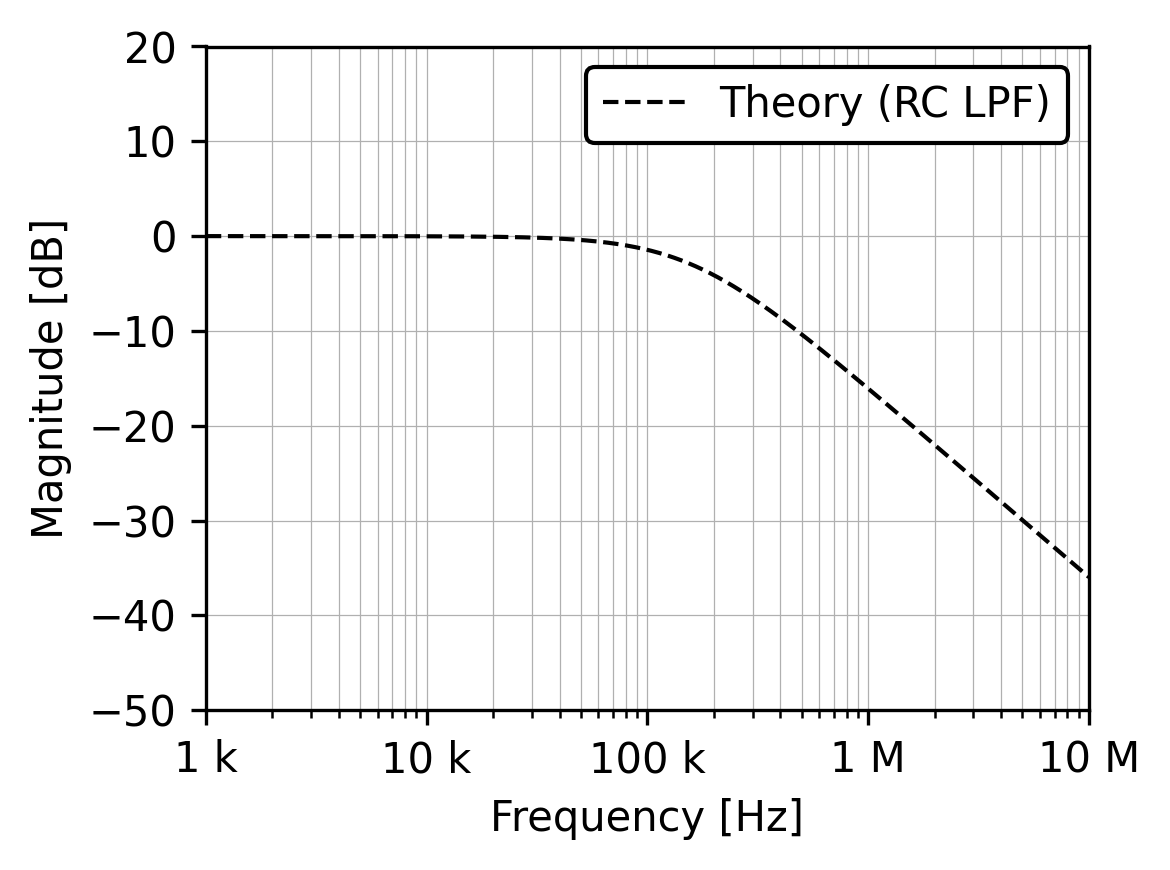

In [9]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy import signal
from matplotlib.ticker import EngFormatter

"""Import simulated data (tsv)"""
# df = pd.read_csv("cad6_data.tsv", sep="\t", header=None)

fs = 1e6
plt_fmin, plt_fmax = 1e3, 1e7
f = np.logspace(np.log10(plt_fmin), np.log10(plt_fmax), 1000)

# 1st-order RC LPF
R, C = 1e6, 1e-12
wc = 1/(R*C)
_, H_LPF = signal.freqs([1], [1/wc, 1], worN=2*np.pi*f)

# Track-and-hold
H_TH = 0.5 + 0.5 * np.sinc(f/(2*fs)) * np.exp(-1j*np.pi*f/(2*fs))

# Sample-and-hold
H_SH = np.sinc(f/fs) * np.exp(-1j*np.pi*f/fs)

plt.figure(figsize=(4, 3), dpi=300)
plt.semilogx(f, 20*np.log10(np.abs(H_LPF)), "--", color='black', lw=1, label="Theory (RC LPF)")

"""Plot chosen sampling theory"""
# plt.semilogx(f, 20*np.log10(np.abs(H)), "-.", color='gray', lw=1, label="Theory (Sampling)")

"""Plot simulated data (tsv)"""
# plt.semilogx(df[0], df[1], "-", color='red', lw=1, label="Simulated SC Filter")

plt.xlabel("Frequency [Hz]"); plt.ylabel("Magnitude [dB]")
plt.xlim(plt_fmin, plt_fmax); plt.ylim(-50, 20)
plt.grid(True, which="both", lw=0.3)
plt.legend(framealpha=1, edgecolor="black")
plt.gca().xaxis.set_major_formatter(EngFormatter(places=0))
plt.tight_layout(); plt.show()
